In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Rows and Columns: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
# Check TotalCharges datatype
df["TotalCharges"].head()


0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [22]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check datatype again
df["TotalCharges"].dtype

dtype('float64')

In [23]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [27]:
# Churn distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# Churn percentage
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 26.54%


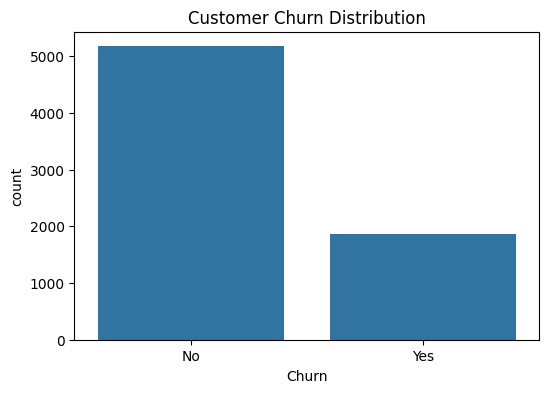

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [29]:
# Remove rows with missing TotalCharges
df = df.dropna()

# Verify
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [35]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


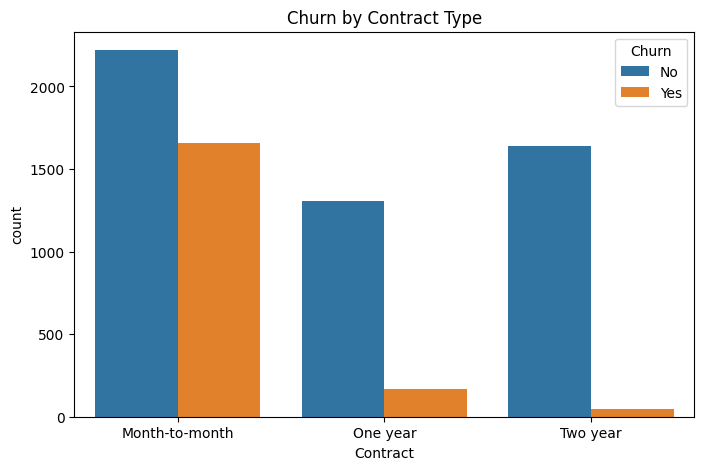

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")
plt.show()

In [39]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


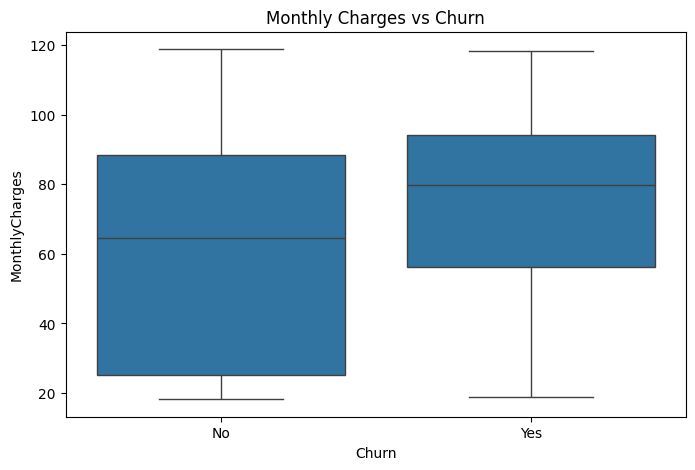

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [36]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


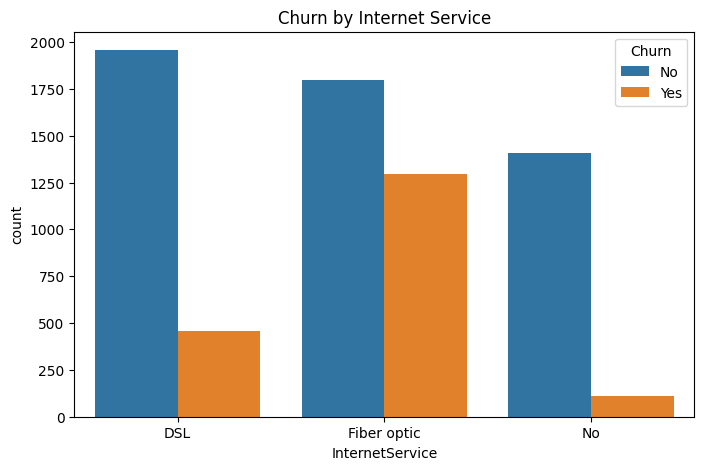

In [ ]:
plt.figure(figsize=(8,5))   

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")
plt.show()

In [40]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


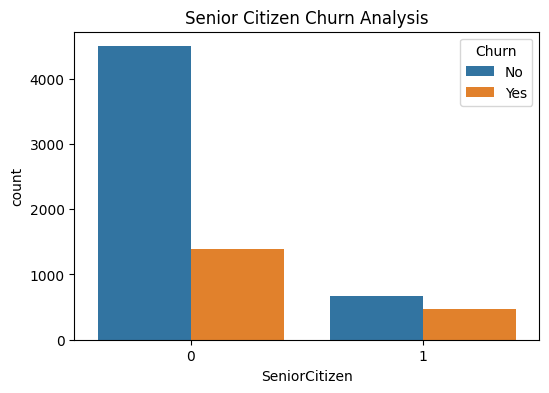

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen Churn Analysis")
plt.show()